EDA of Michael McWaffles' Budget, Earning, and Spending

In [2]:
import pandas as pd

df = pd.read_csv(r'..\data\raw\personal_transactions.csv')
df.head()


,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card


In [3]:
#Add a column to classify transactions as Income, Expense, or Transfer based on the Category column. 
transaction_map = {
    "Paycheck": "Income",
    "Credit Card Payment": "Transfer"
}

df["Transaction Class"] = df["Category"].map(transaction_map)  

df["Transaction Class"] = df["Transaction Class"].fillna("Expense")


In [4]:
#Dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               806 non-null    object 
 1   Description        806 non-null    object 
 2   Amount             806 non-null    float64
 3   Transaction Type   806 non-null    object 
 4   Category           806 non-null    object 
 5   Account Name       806 non-null    object 
 6   Transaction Class  806 non-null    object 
dtypes: float64(1), object(6)
memory usage: 44.2+ KB


In [5]:
#Quick check for missing values
df.isna().sum()

Date                 0
Description          0
Amount               0
Transaction Type     0
Category             0
Account Name         0
Transaction Class    0
dtype: int64

In [6]:
#Amount quick analysis
df.describe()

,Amount
count,806.000000
mean,273.391489
std,667.630374
min,1.750000
25%,15.687500
50%,37.480000
75%,117.680000
max,9200.000000


In [7]:
#Dataframe shape
df.shape

(806, 7)

In [8]:
#Changing the data types of the columns to appropriate types for analysis
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [ ]:
#Create DataFrame for expenses
expenses = df[df["Transaction Class"] == "Expense"]

In [10]:
#Total spending
expenses['Amount'].sum()

np.float64(63042.42)

In [11]:
#Average spending
expenses['Amount'].mean()

np.float64(102.17572123176662)

In [12]:
#Spending by Category
expenses.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Mortgage & Rent           24754.50
Home Improvement          19092.87
Groceries                  2795.21
Utilities                  2776.00
Restaurants                2613.02
Shopping                   1973.24
Gas & Fuel                 1715.17
Mobile Phone               1680.40
Internet                   1570.88
Auto Insurance             1350.00
Electronics & Software      719.00
Alcohol & Bars              539.13
Haircut                     378.00
Fast Food                   330.63
Music                       224.49
Movies & DVDs               222.19
Coffee Shops                115.54
Television                  104.78
Food & Dining                77.75
Entertainment                 9.62
Name: Amount, dtype: float64

In [13]:
#Spending by Description
expenses.groupby('Description')['Amount'].sum().sort_values(ascending=False).head(10)

Description
Mortgage Payment             24754.50
Mike's Construction Co.      17200.00
Grocery Store                 2764.33
Amazon                        1970.04
Hardware Store                1892.87
Phone Company                 1680.40
Internet Service Provider     1570.88
State Farm                    1350.00
Power Company                 1260.00
Gas Company                    781.00
Name: Amount, dtype: float64

In [14]:
#Monthly spending
expenses['Month'] = expenses['Date'].dt.to_period('M')
Monthly_spending = expenses.groupby('Month')['Amount'].sum()
Monthly_spending

C:\Users\acebo\AppData\Local\Temp\ipykernel_5864\1966410109.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expenses['Month'] = expenses['Date'].dt.to_period('M')


Month
2018-01     2066.65
2018-02     2089.44
2018-03     2178.66
2018-04     2862.66
2018-05    10507.56
2018-06     2115.05
2018-07     2302.64
2018-08     1992.68
2018-09     2314.74
2018-10     2242.37
2018-11     2118.15
2018-12     2652.94
2019-01     1736.43
2019-02     1954.60
2019-03     2142.59
2019-04     1966.87
2019-05     2253.41
2019-06    10912.38
2019-07     2551.12
2019-08     2043.20
2019-09     2038.28
Freq: M, Name: Amount, dtype: float64

In [15]:
#Day of the week spending
expenses['Day'] = expenses['Date'].dt.day_name()
expenses.groupby('Day')['Amount'].sum()

C:\Users\acebo\AppData\Local\Temp\ipykernel_5864\1955062091.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expenses['Day'] = expenses['Date'].dt.day_name()


Day
Friday       14900.80
Monday       12069.25
Saturday      2525.90
Sunday        1700.28
Thursday     15948.29
Tuesday      11416.08
Wednesday     4481.82
Name: Amount, dtype: float64

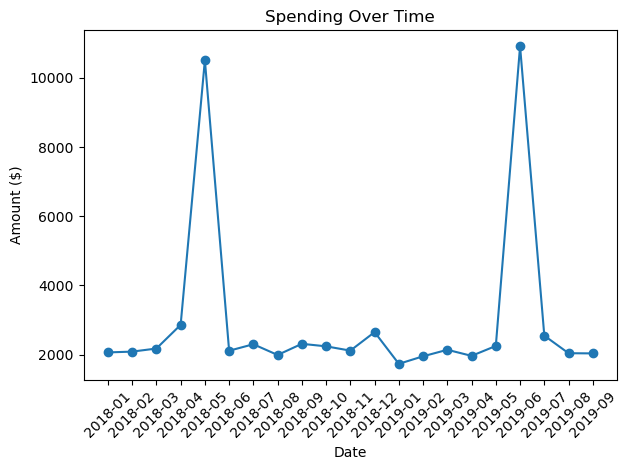

In [16]:
import matplotlib.pyplot as plt

plt.plot(Monthly_spending.index.astype(str), Monthly_spending.values, marker="o")
plt.title("Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
#Simple Outlier Detection
df.sort_values('Amount', ascending=False).head(10)

,Date,Description,Amount,Transaction Type,Category,Account Name,Transaction Class
676,2019-06-20,Mike's Construction Co.,9200.00,debit,Home Improvement,Checking,Expense
172,2018-05-11,Mike's Construction Co.,8000.00,debit,Home Improvement,Checking,Expense
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,Transfer
692,2019-07-05,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income
713,2019-07-19,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income
762,2019-08-30,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income
784,2019-09-13,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income
801,2019-09-27,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income
727,2019-08-02,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income
746,2019-08-16,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income


In [18]:
#Category cleaning check
df['Category'].value_counts()

Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Music                      21
Mobile Phone               21
Mortgage & Rent            21
Internet                   21
Movies & DVDs              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64

In [19]:
#Transaction Type cleaning check
df['Transaction Type'].value_counts()

Transaction Type
debit     688
credit    118
Name: count, dtype: int64

In [20]:
df['is_weekend'] = df['Date'].dt.weekday >= 5

In [21]:
df

,Date,Description,Amount,Transaction Type,Category,Account Name,Transaction Class,is_weekend
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,Expense,False
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,Expense,False
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,Expense,False
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,Transfer,False
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,Expense,False
...,...,...,...,...,...,...,...,...
801,2019-09-27,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income,False
802,2019-09-28,BP,33.46,debit,Gas & Fuel,Platinum Card,Expense,True
803,2019-09-28,Sheetz,4.27,debit,Gas & Fuel,Platinum Card,Expense,True
804,2019-09-30,Starbucks,1.75,debit,Coffee Shops,Platinum Card,Expense,False


In [22]:
pd.crosstab(df["Category"], df["Transaction Type"])

Transaction Type,credit,debit
Category,,
Alcohol & Bars,0,25
Auto Insurance,0,18
Coffee Shops,0,31
Credit Card Payment,72,71
Electronics & Software,0,4
Entertainment,0,1
Fast Food,0,16
Food & Dining,0,2
Gas & Fuel,0,52


In [23]:
#Paycheck Analysis
paychecks = df[df["Category"] == "Paycheck"]

paychecks["Amount"].describe()

count      46.000000
mean     2038.043478
std        90.789612
min      2000.000000
25%      2000.000000
50%      2000.000000
75%      2000.000000
max      2250.000000
Name: Amount, dtype: float64

In [24]:
#All Paychecks
paychecks.sort_values("Date")[["Date", "Amount", "Description"]]

,Date,Amount,Description
13,2018-01-12,2000.0,Biweekly Paycheck
20,2018-01-19,2000.0,Biweekly Paycheck
35,2018-02-02,2000.0,Biweekly Paycheck
51,2018-02-16,2000.0,Biweekly Paycheck
68,2018-03-02,2000.0,Biweekly Paycheck
89,2018-03-16,2000.0,Biweekly Paycheck
104,2018-03-30,2000.0,Biweekly Paycheck
130,2018-04-13,2000.0,Biweekly Paycheck
150,2018-04-27,2000.0,Biweekly Paycheck
171,2018-05-11,2000.0,Biweekly Paycheck


In [25]:
#Paycheck Amount Distribution
paychecks["Amount"].value_counts().sort_index()

Amount
2000.0    39
2250.0     7
Name: count, dtype: int64

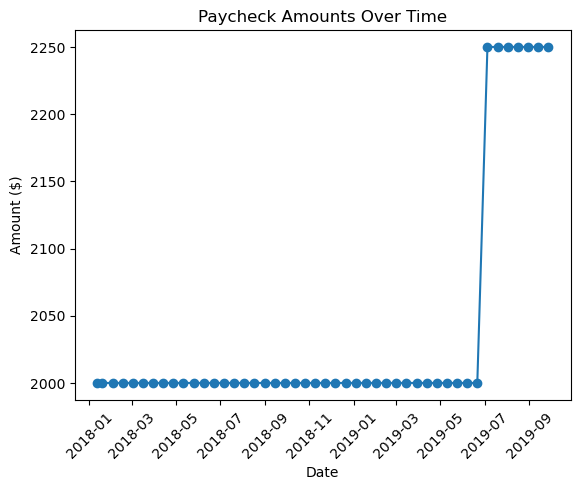

In [26]:
#Plot out the paycheck amounts over time (He got a raise!)
import matplotlib.pyplot as plt

paychecks = paychecks.sort_values("Date")

plt.plot(paychecks["Date"], paychecks["Amount"], marker="o")
plt.title("Paycheck Amounts Over Time")
plt.xlabel("Date")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45)
plt.show()

In [27]:
df

,Date,Description,Amount,Transaction Type,Category,Account Name,Transaction Class,is_weekend
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,Expense,False
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,Expense,False
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,Expense,False
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,Transfer,False
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,Expense,False
...,...,...,...,...,...,...,...,...
801,2019-09-27,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income,False
802,2019-09-28,BP,33.46,debit,Gas & Fuel,Platinum Card,Expense,True
803,2019-09-28,Sheetz,4.27,debit,Gas & Fuel,Platinum Card,Expense,True
804,2019-09-30,Starbucks,1.75,debit,Coffee Shops,Platinum Card,Expense,False


In [28]:
#Aggragate spending by category
category_spending = (
    expenses.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

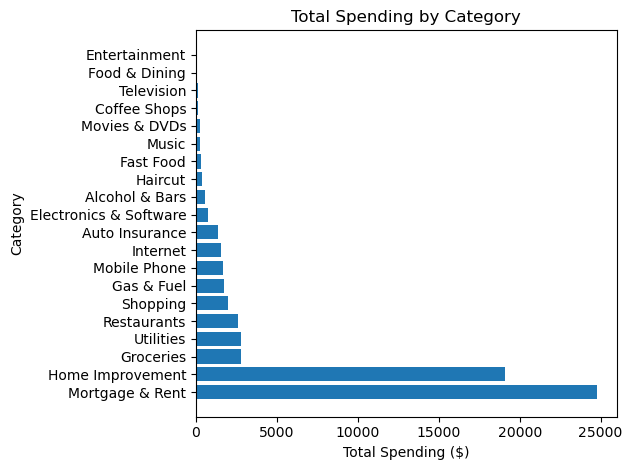

In [29]:
#Plot spending by category
 
import matplotlib.pyplot as plt

plt.barh(
    category_spending.index,
    category_spending.values
)

plt.title("Total Spending by Category")
plt.xlabel("Total Spending ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

df2 = pd.read_csv(r'..\data\raw\Budget.csv')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               806 non-null    datetime64[ns]
 1   Description        806 non-null    object        
 2   Amount             806 non-null    float64       
 3   Transaction Type   806 non-null    object        
 4   Category           806 non-null    object        
 5   Account Name       806 non-null    object        
 6   Transaction Class  806 non-null    object        
 7   is_weekend         806 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), object(5)
memory usage: 45.0+ KB


In [32]:
df2

,Category,Budget
0,Alcohol & Bars,50
1,Auto Insurance,75
2,Coffee Shops,15
3,Electronics & Software,0
4,Entertainment,25
5,Fast Food,15
6,Gas & Fuel,75
7,Groceries,150
8,Haircut,30
9,Home Improvement,250


In [33]:
#Checking if any categories in the expenses DataFrame are not present in the Budget DataFrame
set(expenses["Category"]) - set(df2["Category"])

{'Food & Dining'}

In [34]:
#Opposite check: Checking if any categories in the Budget DataFrame are not present in the expenses DataFrame
set(df2["Category"]) - set(expenses["Category"])

set()

In [35]:
#Join the two DataFrames to compare actual spending vs budgeted amounts
monthly_spending = (
    expenses
    .groupby(["Month", "Category"], as_index=False)["Amount"]
    .sum()
)

comparison = monthly_spending.merge(df2, on="Category", how="left")

In [36]:
comparison

,Month,Category,Amount,Budget
0,2018-01,Coffee Shops,3.00,15.0
1,2018-01,Fast Food,32.91,15.0
2,2018-01,Gas & Fuel,65.29,75.0
3,2018-01,Groceries,87.73,150.0
4,2018-01,Home Improvement,51.21,250.0
...,...,...,...,...
293,2019-09,Music,10.69,11.0
294,2019-09,Restaurants,172.34,150.0
295,2019-09,Shopping,85.38,100.0
296,2019-09,Television,13.90,15.0


In [37]:
#Create a difference column to compare actual spending vs budgeted amounts
comparison["Difference"] = comparison["Amount"] - comparison["Budget"]

In [38]:
comparison

,Month,Category,Amount,Budget,Difference
0,2018-01,Coffee Shops,3.00,15.0,-12.00
1,2018-01,Fast Food,32.91,15.0,17.91
2,2018-01,Gas & Fuel,65.29,75.0,-9.71
3,2018-01,Groceries,87.73,150.0,-62.27
4,2018-01,Home Improvement,51.21,250.0,-198.79
...,...,...,...,...,...
293,2019-09,Music,10.69,11.0,-0.31
294,2019-09,Restaurants,172.34,150.0,22.34
295,2019-09,Shopping,85.38,100.0,-14.62
296,2019-09,Television,13.90,15.0,-1.10


In [39]:
#Filter data for the most recent month
selected_month = monthly_spending["Month"].max()

month_data = monthly_spending[
    monthly_spending["Month"] == selected_month
]

In [40]:
#Merge for recent month
comparison = month_data.merge(
    df2,
    on="Category",
    how="left"
)

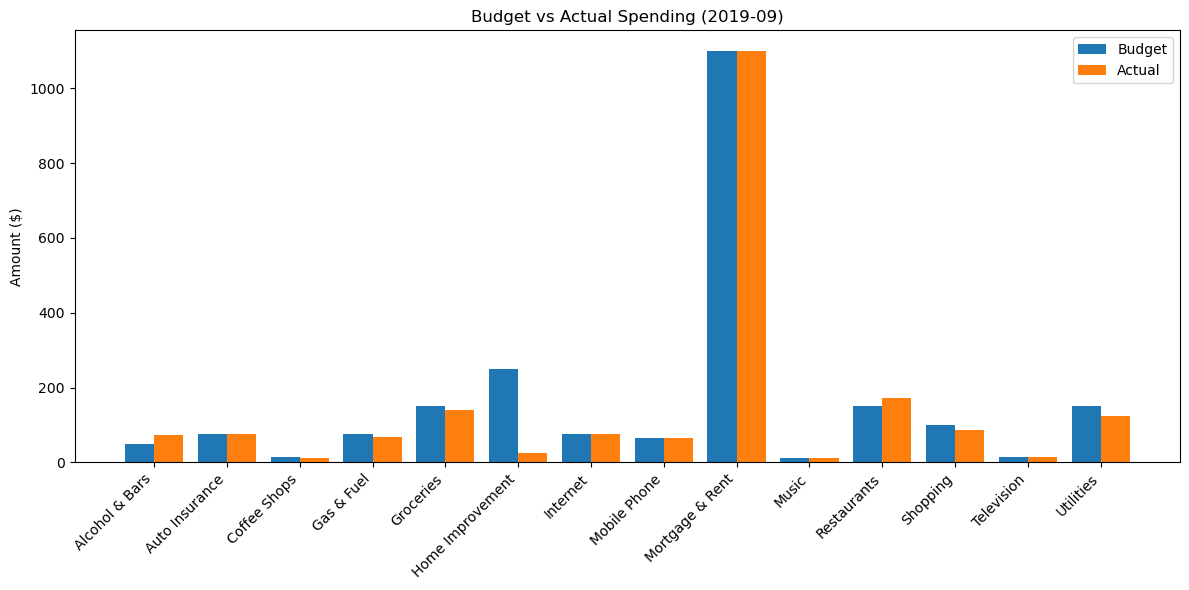

In [41]:
import numpy as np

x = np.arange(len(comparison))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    comparison["Budget"],
    width,
    label="Budget"
)

plt.bar(
    x + width/2,
    comparison["Amount"],
    width,
    label="Actual"
)

plt.xticks(x, comparison["Category"], rotation=45, ha="right")
plt.ylabel("Amount ($)")
plt.title(f"Budget vs Actual Spending ({selected_month})")
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
#Partner asked for simulated data for the Description column to make it look more like actual purchase names. The following code will randomly select a merchant name and from a predefined list based on the category of the transaction. Then generate a random code at the end.
import numpy as np
import string
import random

merchant_map = {
    "Alcohol & Bars": [
        "TIPSY TAP BAR & GRILL",
        "RED LANTERN PUB",
        "MIXOLOGY LOUNGE"
    ],
    "Auto Insurance": [
        "GEICO INSURANCE PAYMENT",
        "STATE FARM AUTO BILL",
        "PROGRESSIVE INSURANCE"
    ],
    "Coffee Shops": [
        "SQ *STARBUCKS STORE 1123",
        "DUNKIN #34567",
        "PEET'S COFFEE ROASTERS"
    ],
    "Electronics & Software": [
        "AMZN MKTPLACE SOFTWARE",
        "APPLE.COM/BILL",
        "MICROSOFT*SUBSCRIPTION"
    ],
    "Entertainment": [
        "NETFLIX.COM",
        "HULU STREAMING SERVICE",
        "SPOTIFY PREMIUM"
    ],
    "Fast Food": [
        "MCDONALD'S #18452",
        "CHIPOTLE MEXICAN GRILL",
        "TACO BELL #2231"
    ],
    "Gas & Fuel": [
        "SHELL OIL",
        "CASEY'S GENERAL STORE 6672",
        "MOBIL FUEL STATION"
    ],
    "Groceries": [
        "WALMART SUPERCENTER",
        "JEWEL-OSCO",
        "TARGET GROCERY"
    ],
    "Haircut": [
        "SPORT CLIPS HAIRCUT",
        "GREAT CLIPS SALON",
        "LOCAL BARBER SHOP"
    ],
    "Home Improvement": [
        "HOME DEPOT 5244",
        "LOWE'S STORE 8832",
        "MENARDS ROCKFORD"
    ],
    "Internet": [
        "COMCAST XFINITY BILL",
        "CHARTER SPECTRUM",
        "AT&T INTERNET SERVICE"
    ],
    "Mobile Phone": [
        "VERIZON WIRELESS BILL",
        "T-MOBILE PAYMENT",
        "AT&T MOBILE SERVICE"
    ],
    "Mortgage & Rent": [
        "APARTMENT RENT PAYMENT",
        "ZILLOW RENT PORTAL",
        "MORTGAGE LOAN PAYMENT"
    ],
    "Movies & DVDs": [
        "AMC THEATERS TICKET",
        "FANDANGO MOVIE PURCHASE",
        "REGAL CINEMAS"
    ],
    "Music": [
        "SPOTIFY PREMIUM",
        "APPLE MUSIC SUBSCRIPTION",
        "YOUTUBE MUSIC"
    ],
    "Restaurants": [
        "OLIVE GARDEN 4452",
        "CHILI'S GRILL & BAR",
        "LOCAL DINER PURCHASE"
    ],
    "Shopping": [
        "AMAZON.COM PURCHASE",
        "TARGET STORE 1456",
        "WALMART ONLINE ORDER"
    ],
    "Television": [
        "NETFLIX SUBSCRIPTION",
        "HBO MAX BILL",
        "DISNEY+ MONTHLY"
    ],
    "Utilities": [
        "CITY ELECTRIC BILL",
        "WATER DEPARTMENT PAYMENT",
        "NATURAL GAS SERVICE"
    ],
}

def cryptic_code(n=6):
    return "".join(
        random.choices(string.ascii_uppercase + string.digits, k=n)
    )

def generate_description(row):
    category = row["Category"]

    base = merchant_map.get(category, ["UNKNOWN MERCHANT"])
    merchant = np.random.choice(base)

    code = cryptic_code()

    return f"{merchant} #{code}"

df["Transaction Code"] = df.apply(generate_description, axis=1)

In [58]:
df

,Date,Description,Amount,Transaction Type,Category,Account Name,Transaction Class,is_weekend,Transaction Code
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,Expense,False,TARGET STORE 1456 #DFGWFD
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,Expense,False,ZILLOW RENT PORTAL #9M7JEX
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,Expense,False,CHILI'S GRILL & BAR #YDE51Q
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,Transfer,False,UNKNOWN MERCHANT #RZ3O90
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,Expense,False,AMC THEATERS TICKET #FMDTV9
...,...,...,...,...,...,...,...,...,...
801,2019-09-27,Biweekly Paycheck,2250.00,credit,Paycheck,Checking,Income,False,UNKNOWN MERCHANT #QLU0LB
802,2019-09-28,BP,33.46,debit,Gas & Fuel,Platinum Card,Expense,True,MOBIL FUEL STATION #GUDN3B
803,2019-09-28,Sheetz,4.27,debit,Gas & Fuel,Platinum Card,Expense,True,CASEY'S GENERAL STORE 6672 #YVF65P
804,2019-09-30,Starbucks,1.75,debit,Coffee Shops,Platinum Card,Expense,False,PEET'S COFFEE ROASTERS #VOW3P6


In [68]:
#Convert all column names to snake case
df = df.rename(columns={
    "Date": "transaction_date",
    "Amount": "amount",
    "Account": "account_name",
    "Category": "category_name",
    "Description": "description",
    "Transaction Type": "transaction_type",
    "Transaction Class": "transaction_class",
    "Transaction Code": "transaction_code"
})

df2 = df2.rename(columns={
    "Category": "category_name",
    "Budget": "monthly_budget"
})

In [63]:
#Build the categories table
categories = (
    df[["category_name", "transaction_class"]]
    .drop_duplicates()
    .sort_values("category_name")
    .reset_index(drop=True)
)

categories["category_id"] = categories.index + 1

In [ ]:
#Create the transactions table by merging with the categories table to get the category_id
transactions = df.merge(
    categories,
    on=["category_name", "transaction_class"],
    how="left"
)

In [ ]:
#Filter the transactions DataFrame to include only the necessary columns
transactions = transactions[
    [
        "transaction_date",
        "amount",
        "description",
        "transaction_type",
        "category_id",
        "transaction_code"
    ]
]

In [ ]:
#Create the budgets DataFrame by merging with the categories DataFrame to get the category_id
budgets = df2.merge(
    categories[["category_name", "category_id"]],
    on="category_name",
    how="left"
)

In [ ]:
#Filter the budgets DataFrame to include only the necessary columns
budgets = budgets[
    [
        "category_id",
        "Budget"
    ]
]

In [ ]:
#Save the processed data to CSV files
transactions.to_csv(
    "../data/processed/transactions.csv",
    index=False
)

categories.to_csv(
    "../data/processed/categories.csv",
    index=False
)

budgets.to_csv(
    "../data/processed/budgets.csv",
    index=False
)